In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib


def train_xgb_lgbm_ensemble():
    data_path  = r'C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Data Pre Process\Combining DataSets\Final_Combined_data.csv'
    output_dir = r'C:\Users\Ranuga\Data Science Project\Final Complete Dataset\Model Building'
    os.makedirs(output_dir, exist_ok=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 1. Load
    # ─────────────────────────────────────────────────────────────────────────
    print("Loading data...")
    df = pd.read_csv(data_path)
    print(f"  Dataset shape: {df.shape}")

    # Drop unused identifier columns
    df.drop(columns=['code'], inplace=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 2. Feature Engineering
    # ─────────────────────────────────────────────────────────────────────────

    # Cyclic week encoding
    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    # Regional weather aggregates per zone per week
    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum', 'mean_apparent_temperature']]
        .mean()
        .reset_index()
        .rename(columns={'rain_sum': 'reg_rain', 'mean_apparent_temperature': 'reg_temp'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')

    # Year_Week only needed for the weather merge above — drop it now
    df.drop(columns=['Year_Week'], inplace=True)

    # Seasonality & diesel interaction
    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)

    # Sort for time-series lags
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    # Lags for retail_price, farmer_price, and weather
    for col in ['retail_price', 'reg_rain', 'reg_temp']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    # Farmer price — more granular lags to give it higher model influence
    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    # Rolling stats for retail price (4-week mean)
    df['retail_price_roll_4'] = (
        df.groupby(['retail_market', 'vegetable_type'])['retail_price']
        .transform(lambda x: x.shift(1).rolling(4).mean())
    )

    # ── Farmer price rolling features (richer signal) ──────────────────────
    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    # Short & long rolling mean
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    # Volatility: rolling std (price stability signal)
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    # Week-over-week % change in farmer price (momentum)
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    # ── Current-week farmer price (impute nulls with lag_1 — strongest signal) ──
    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    # Retail-farmer spread (lag_1): captures markup/margin signal
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    # Drop rows where longest lag hasn't filled yet
    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8',
                                  'farmer_price_roll_8']).copy()

    # Encode categoricals
    le_dict = {}
    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        le = LabelEncoder()
        df_ready[f'{col}_enc'] = le.fit_transform(df_ready[col].astype(str))
        le_dict[col] = le

    # ─────────────────────────────────────────────────────────────────────────
    # 3. Train / Test Split  (80 / 20 per group, time-ordered)
    # ─────────────────────────────────────────────────────────────────────────
    train_list, test_list = [], []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    # ─────────────────────────────────────────────────────────────────────────
    # 4. Feature list
    # ─────────────────────────────────────────────────────────────────────────
    features = [
        # ── HIGHEST WEIGHT: direct farmer price signal ──────────────────────
        'mean_farmer_price_filled',     # current-week farmer price (strongest predictor)
        'farmer_retail_spread_lag_1',   # lagged retail-farmer markup
        # Farmer price lags & rolling
        'mean_farmer_price_lag_1', 'mean_farmer_price_lag_2',
        'mean_farmer_price_lag_3', 'mean_farmer_price_lag_4',
        'mean_farmer_price_lag_5', 'mean_farmer_price_lag_6',
        'mean_farmer_price_lag_8',
        'farmer_price_roll_4',
        'farmer_price_roll_8',
        'farmer_price_roll_std_4',
        'farmer_price_pct_change_1',
        # Time
        'year', 'week_sin', 'week_cos',
        # Macro-economic
        'lanka_auto_diesel_price', 'usd_exchange_rate', 'diesel_season_int',
        # Holidays
        'no_of_holidays',
        # Weather
        'reg_rain', 'reg_temp',
        # Retail price lags
        'retail_price_lag_1', 'retail_price_lag_2',
        'retail_price_lag_3', 'retail_price_lag_4', 'retail_price_lag_8',
        # Weather lags
        'reg_rain_lag_1', 'reg_rain_lag_4', 'reg_rain_lag_8',
        'reg_temp_lag_1', 'reg_temp_lag_4', 'reg_temp_lag_8',
        # Rolling retail
        'retail_price_roll_4',
        # Categoricals
        'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'season_enc',
    ]

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']

    print(f"\n  Train rows : {len(train_df):,}")
    print(f"  Test rows  : {len(test_df):,}")
    print(f"  Features   : {len(features)}")

    # ─────────────────────────────────────────────────────────────────────────
    # 5. Train Models
    # ─────────────────────────────────────────────────────────────────────────
    print("\nTraining Ensemble Members...")

    # ── XGBoost ──────────────────────────────────────────────────────────────
    print("  [1/2] Training XGBoost...")
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
    )
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    best_xgb_iter = model_xgb.best_iteration
    print(f"     Best iteration: {best_xgb_iter}")

    # ── LightGBM ─────────────────────────────────────────────────────────────
    print("  [2/2] Training LightGBM...")
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    best_lgb_iter = model_lgb.best_iteration_
    print(f"     Best iteration: {best_lgb_iter}")

    # ─────────────────────────────────────────────────────────────────────────
    # 6. Weighted Ensemble  (equal weight — both are boosting models)
    # ─────────────────────────────────────────────────────────────────────────
    print("\nBuilding Weighted Ensemble Predictions...")
    pred_xgb   = model_xgb.predict(X_test)
    pred_lgb   = model_lgb.predict(X_test)
    final_pred = (0.5 * pred_xgb) + (0.5 * pred_lgb)

    # ─────────────────────────────────────────────────────────────────────────
    # 7. Evaluation
    # ─────────────────────────────────────────────────────────────────────────
    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb)

    report = f"""XGBoost + LightGBM Ensemble – Performance Report
=================================================
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  ({df.shape[0]:,} rows total)
Train   : {len(train_df):,} rows | Test: {len(test_df):,} rows
Features: {len(features)}

Model Tuning Details
--------------------
  XGBoost  best iteration : {best_xgb_iter}
  LightGBM best iteration : {best_lgb_iter}

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%

Individual Model Accuracies
---------------------------
  XGBoost  : {(1 - mape_xgb)*100:.2f}%
  LightGBM : {(1 - mape_lgb)*100:.2f}%

Conclusion
----------
XGBoost and LightGBM are complementary gradient-boosting frameworks.
XGBoost uses depth-wise tree growth (more accurate on structured tabular data
with outliers), while LightGBM uses leaf-wise growth (faster, handles
high-cardinality categoricals better). Their ensemble averages out
individual model variance for more stable retail price predictions.
"""

    print("\n" + report)

    report_path = os.path.join(output_dir, 'xgb_lgbm_ensemble_performance.txt')
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)
    print(f"Performance report saved -> {report_path}")

    # ─────────────────────────────────────────────────────────────────────────
    # 8. Save Model Bundle
    # ─────────────────────────────────────────────────────────────────────────
    bundle = {
        'xgb'            : model_xgb,
        'lgb'            : model_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': 0.5, 'lgb': 0.5},
    }
    model_path = os.path.join(output_dir, 'xgb_lgbm_ensemble_model.joblib')
    joblib.dump(bundle, model_path)
    print(f"Model bundle saved      -> {model_path}")


if __name__ == "__main__":
    train_xgb_lgbm_ensemble()


Loading data...
  Dataset shape: (61152, 15)

  Train rows : 45,579
  Test rows  : 11,546
  Features   : 38

Training Ensemble Members...
  [1/2] Training XGBoost...
     Best iteration: 168
  [2/2] Training LightGBM...
     Best iteration: 180

Building Weighted Ensemble Predictions...

XGBoost + LightGBM Ensemble – Performance Report
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  (61,152 rows total)
Train   : 45,579 rows | Test: 11,546 rows
Features: 38

Model Tuning Details
--------------------
  XGBoost  best iteration : 168
  LightGBM best iteration : 180

Overall Ensemble Metrics
------------------------
  R2  Score              : 0.9300
  Accuracy (1 - MAPE)    : 90.75%
  MAPE                   : 9.25%

Individual Model Accuracies
---------------------------
  XGBoost  : 90.69%
  LightGBM : 90.71%

Conclusion
----------
XGBoost and LightGBM are complementary gradie

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib


def train_xgb_lgbm_ensemble():
    # Updated paths to match the new folder structure
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    model_dir  = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\Models'
    report_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\Reports'
    
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 1. Load
    # ─────────────────────────────────────────────────────────────────────────
    print("Loading data...")
    df = pd.read_csv(data_path)
    print(f"  Dataset shape: {df.shape}")

    # Drop unused identifier columns
    df.drop(columns=['code'], inplace=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 2. Feature Engineering
    # ─────────────────────────────────────────────────────────────────────────

    # Cyclic week encoding
    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    # Regional weather aggregates per zone per week (Rain Only)
    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum']]
        .mean()
        .reset_index()
        .rename(columns={'rain_sum': 'reg_rain'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')

    # Year_Week only needed for the weather merge above — drop it now
    df.drop(columns=['Year_Week'], inplace=True)

    # Seasonality & diesel interaction
    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)

    # Sort for time-series lags
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    # Lags for retail_price and rain
    for col in ['retail_price', 'reg_rain']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    # Farmer price — more granular lags to give it higher model influence
    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    # Rolling stats for retail price (4-week mean)
    df['retail_price_roll_4'] = (
        df.groupby(['retail_market', 'vegetable_type'])['retail_price']
        .transform(lambda x: x.shift(1).rolling(4).mean())
    )

    # ── Farmer price rolling features (richer signal) ──────────────────────
    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    # Short & long rolling mean
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    # Volatility: rolling std (price stability signal)
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    # Week-over-week % change in farmer price (momentum)
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    # ── Current-week farmer price (impute nulls with lag_1 — strongest signal) ──
    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    # Retail-farmer spread (lag_1): captures markup/margin signal
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    # Drop rows where longest lag hasn't filled yet
    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8',
                                  'farmer_price_roll_8']).copy()

    # Encode categoricals
    le_dict = {}
    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        le = LabelEncoder()
        df_ready[f'{col}_enc'] = le.fit_transform(df_ready[col].astype(str))
        le_dict[col] = le

    # ─────────────────────────────────────────────────────────────────────────
    # 3. Train / Test Split  (80 / 20 per group, time-ordered)
    # ─────────────────────────────────────────────────────────────────────────
    train_list, test_list = [], []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    # ─────────────────────────────────────────────────────────────────────────
    # 4. Feature list
    # ─────────────────────────────────────────────────────────────────────────
    features = [
        # ── HIGHEST WEIGHT: direct farmer price signal ──────────────────────
        'mean_farmer_price_filled',     # current-week farmer price (strongest predictor)
        'farmer_retail_spread_lag_1',   # lagged retail-farmer markup
        # Farmer price lags & rolling
        'mean_farmer_price_lag_1', 'mean_farmer_price_lag_2',
        'mean_farmer_price_lag_3', 'mean_farmer_price_lag_4',
        'mean_farmer_price_lag_5', 'mean_farmer_price_lag_6',
        'mean_farmer_price_lag_8',
        'farmer_price_roll_4',
        'farmer_price_roll_8',
        'farmer_price_roll_std_4',
        'farmer_price_pct_change_1',
        # Time
        'year', 'week_sin', 'week_cos',
        # Macro-economic
        'lanka_auto_diesel_price', 'usd_exchange_rate', 'diesel_season_int',
        # Holidays
        'no_of_holidays',
        # Weather (Rain Only)
        'reg_rain', 
        # Retail price lags
        'retail_price_lag_1', 'retail_price_lag_2',
        'retail_price_lag_3', 'retail_price_lag_4', 'retail_price_lag_8',
        # Weather lags (Rain Only)
        'reg_rain_lag_1', 'reg_rain_lag_4', 'reg_rain_lag_8',
        # Rolling retail
        'retail_price_roll_4',
        # Categoricals
        'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'season_enc',
    ]

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']

    print(f"\n  Train rows : {len(train_df):,}")
    print(f"  Test rows  : {len(test_df):,}")
    print(f"  Features   : {len(features)}")

    # ─────────────────────────────────────────────────────────────────────────
    # 5. Train Models
    # ─────────────────────────────────────────────────────────────────────────
    print("\nTraining Ensemble Members...")

    # ── XGBoost ──────────────────────────────────────────────────────────────
    print("  [1/2] Training XGBoost...")
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
    )
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    best_xgb_iter = model_xgb.best_iteration
    print(f"     Best iteration: {best_xgb_iter}")

    # ── LightGBM ─────────────────────────────────────────────────────────────
    print("  [2/2] Training LightGBM...")
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    best_lgb_iter = model_lgb.best_iteration_
    print(f"     Best iteration: {best_lgb_iter}")

    # ─────────────────────────────────────────────────────────────────────────
    # 6. Weighted Ensemble  (equal weight — both are boosting models)
    # ─────────────────────────────────────────────────────────────────────────
    print("\nBuilding Weighted Ensemble Predictions...")
    pred_xgb   = model_xgb.predict(X_test)
    pred_lgb   = model_lgb.predict(X_test)
    final_pred = (0.5 * pred_xgb) + (0.5 * pred_lgb)

    # ─────────────────────────────────────────────────────────────────────────
    # 7. Evaluation
    # ─────────────────────────────────────────────────────────────────────────
    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb)

    report = f"""XGBoost + LightGBM Ensemble – Performance Report (Rain Features Only)
=================================================
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  ({df.shape[0]:,} rows total)
Train   : {len(train_df):,} rows | Test: {len(test_df):,} rows
Features: {len(features)}

Model Tuning Details
--------------------
  XGBoost  best iteration : {best_xgb_iter}
  LightGBM best iteration : {best_lgb_iter}

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%

Individual Model Accuracies
---------------------------
  XGBoost  : {(1 - mape_xgb)*100:.2f}%
  LightGBM : {(1 - mape_lgb)*100:.2f}%

Conclusion
----------
XGBoost and LightGBM are complementary gradient-boosting frameworks.
XGBoost uses depth-wise tree growth (more accurate on structured tabular data
with outliers), while LightGBM uses leaf-wise growth (faster, handles
high-cardinality categoricals better). Their ensemble averages out
individual model variance for more stable retail price predictions.
"""

    print("\n" + report)

    report_name = os.path.join(report_dir, 'xgb_lgbm_ensemble_performance.txt')
    with open(report_name, 'w', encoding='utf-8') as f:
        f.write(report)
    print(f"Performance report saved -> {report_name}")

    # ─────────────────────────────────────────────────────────────────────────
    # 8. Save Model Bundle
    # ─────────────────────────────────────────────────────────────────────────
    bundle = {
        'xgb'            : model_xgb,
        'lgb'            : model_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': 0.5, 'lgb': 0.5},
    }
    model_name = os.path.join(model_dir, 'xgb_lgbm_ensemble_model.joblib')
    joblib.dump(bundle, model_name)
    print(f"Model bundle saved      -> {model_name}")


if __name__ == "__main__":
    train_xgb_lgbm_ensemble()


Loading data...
  Dataset shape: (61152, 15)

  Train rows : 45,579
  Test rows  : 11,546
  Features   : 34

Training Ensemble Members...
  [1/2] Training XGBoost...
     Best iteration: 131
  [2/2] Training LightGBM...
     Best iteration: 126

Building Weighted Ensemble Predictions...

XGBoost + LightGBM Ensemble – Performance Report (Rain Features Only)
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  (61,152 rows total)
Train   : 45,579 rows | Test: 11,546 rows
Features: 34

Model Tuning Details
--------------------
  XGBoost  best iteration : 131
  LightGBM best iteration : 126

Overall Ensemble Metrics
------------------------
  R2  Score              : 0.9291
  Accuracy (1 - MAPE)    : 90.68%
  MAPE                   : 9.32%

Individual Model Accuracies
---------------------------
  XGBoost  : 90.63%
  LightGBM : 90.63%

Conclusion
----------
XGBoost and LightGBM are

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib

def train_xgb_lgbm_ensemble():
    # Updated paths to match the new folder structure
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    model_dir  = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Models'
    report_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Reports'
    
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 1. Load
    # ─────────────────────────────────────────────────────────────────────────
    print("Loading data...")
    df = pd.read_csv(data_path)
    print(f"  Dataset shape: {df.shape}")

    # Drop unused identifier columns
    df.drop(columns=['code'], inplace=True)

    # ─────────────────────────────────────────────────────────────────────────
    # 2. Feature Engineering
    # ─────────────────────────────────────────────────────────────────────────

    # Cyclic week encoding
    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    # Regional weather aggregates per zone per week (Rain Only)
    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum']]
        .mean()
        .reset_index()
        .rename(columns={'rain_sum': 'reg_rain'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')

    # Year_Week only needed for the weather merge above — drop it now
    df.drop(columns=['Year_Week'], inplace=True)

    # Encode Seasonality (Keeping just season_enc, diesel integration is REMOVED)
    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    # df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)  <-- REMOVED

    # Sort for time-series lags
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    # Lags for retail_price and rain
    for col in ['retail_price', 'reg_rain']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    # Farmer price — more granular lags to give it higher model influence
    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    # Rolling stats for retail price (4-week mean)
    df['retail_price_roll_4'] = (
        df.groupby(['retail_market', 'vegetable_type'])['retail_price']
        .transform(lambda x: x.shift(1).rolling(4).mean())
    )

    # ── Farmer price rolling features (richer signal) ──────────────────────
    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    # Short & long rolling mean
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    # Volatility: rolling std (price stability signal)
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    # Week-over-week % change in farmer price (momentum)
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    # ── Current-week farmer price (impute nulls with lag_1 — strongest signal) ──
    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    # Retail-farmer spread (lag_1): captures markup/margin signal
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    # Drop rows where longest lag hasn't filled yet
    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8',
                                  'farmer_price_roll_8']).copy()

    # Encode categoricals
    le_dict = {}
    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        le = LabelEncoder()
        df_ready[f'{col}_enc'] = le.fit_transform(df_ready[col].astype(str))
        le_dict[col] = le

    # ─────────────────────────────────────────────────────────────────────────
    # 3. Train / Test Split  (80 / 20 per group, time-ordered)
    # ─────────────────────────────────────────────────────────────────────────
    train_list, test_list = [], []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    # ─────────────────────────────────────────────────────────────────────────
    # 4. Feature list (Diesel removed entirely)
    # ─────────────────────────────────────────────────────────────────────────
    features = [
        # ── HIGHEST WEIGHT: direct farmer price signal ──────────────────────
        'mean_farmer_price_filled',     # current-week farmer price (strongest predictor)
        'farmer_retail_spread_lag_1',   # lagged retail-farmer markup
        # Farmer price lags & rolling
        'mean_farmer_price_lag_1', 'mean_farmer_price_lag_2',
        'mean_farmer_price_lag_3', 'mean_farmer_price_lag_4',
        'mean_farmer_price_lag_5', 'mean_farmer_price_lag_6',
        'mean_farmer_price_lag_8',
        'farmer_price_roll_4',
        'farmer_price_roll_8',
        'farmer_price_roll_std_4',
        'farmer_price_pct_change_1',
        # Time
        'year', 'week_sin', 'week_cos',
        # Macro-economic (Only USD Exchange Rate Kept)
        'usd_exchange_rate',
        # Holidays
        'no_of_holidays',
        # Weather (Rain Only)
        'reg_rain', 
        # Retail price lags
        'retail_price_lag_1', 'retail_price_lag_2',
        'retail_price_lag_3', 'retail_price_lag_4', 'retail_price_lag_8',
        # Weather lags (Rain Only)
        'reg_rain_lag_1', 'reg_rain_lag_4', 'reg_rain_lag_8',
        # Rolling retail
        'retail_price_roll_4',
        # Categoricals
        'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'season_enc',
    ]

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']

    print(f"\n  Train rows : {len(train_df):,}")
    print(f"  Test rows  : {len(test_df):,}")
    print(f"  Features   : {len(features)}")

    # ─────────────────────────────────────────────────────────────────────────
    # 5. Train Models
    # ─────────────────────────────────────────────────────────────────────────
    print("\nTraining Ensemble Members...")

    # ── XGBoost ───────────────────────────────────────────────────────────────
    print("  [1/2] Training XGBoost...")
    model_xgb = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=50,
    )
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )
    best_xgb_iter = model_xgb.best_iteration
    print(f"     Best iteration: {best_xgb_iter}")

    # ── LightGBM ───────────────────────────────────────────────────────────────
    print("  [2/2] Training LightGBM...")
    model_lgb = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model_lgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )
    best_lgb_iter = model_lgb.best_iteration_
    print(f"     Best iteration: {best_lgb_iter}")

    # ─────────────────────────────────────────────────────────────────────────
    # 6. Weighted Ensemble  (equal weight — both are boosting models)
    # ─────────────────────────────────────────────────────────────────────────
    print("\nBuilding Weighted Ensemble Predictions...")
    pred_xgb   = model_xgb.predict(X_test)
    pred_lgb   = model_lgb.predict(X_test)
    final_pred = (0.5 * pred_xgb) + (0.5 * pred_lgb)

    # ─────────────────────────────────────────────────────────────────────────
    # 7. Evaluation
    # ─────────────────────────────────────────────────────────────────────────
    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb)

    report = f"""XGBoost + LightGBM Ensemble – Performance Report (No Diesel Features)
===============================================================
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  ({df.shape[0]:,} rows total)
Train   : {len(train_df):,} rows | Test: {len(test_df):,} rows
Features: {len(features)}

Model Tuning Details
--------------------
  XGBoost  best iteration : {best_xgb_iter}
  LightGBM best iteration : {best_lgb_iter}

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%

Individual Model Accuracies
---------------------------
  XGBoost  : {(1 - mape_xgb)*100:.2f}%
  LightGBM : {(1 - mape_lgb)*100:.2f}%

Conclusion
----------
XGBoost and LightGBM are complementary gradient-boosting frameworks.
XGBoost uses depth-wise tree growth (more accurate on structured tabular data
with outliers), while LightGBM uses leaf-wise growth (faster, handles
high-cardinality categoricals better). Their ensemble averages out
individual model variance for more stable retail price predictions.
"""

    print("\n" + report)

    report_name = os.path.join(report_dir, 'xgb_lgbm_ensemble_no_diesel_performance.txt')
    with open(report_name, 'w', encoding='utf-8') as f:
        f.write(report)
    print(f"Performance report saved -> {report_name}")

    # ─────────────────────────────────────────────────────────────────────────
    # 8. Save Model Bundle
    # ─────────────────────────────────────────────────────────────────────────
    bundle = {
        'xgb'            : model_xgb,
        'lgb'            : model_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': 0.5, 'lgb': 0.5},
    }
    model_name = os.path.join(model_dir, 'xgb_lgbm_ensemble_no_diesel_model.joblib')
    joblib.dump(bundle, model_name)
    print(f"Model bundle saved      -> {model_name}")


if __name__ == "__main__":
    train_xgb_lgbm_ensemble()

Loading data...
  Dataset shape: (61152, 15)

  Train rows : 45,579
  Test rows  : 11,546
  Features   : 32

Training Ensemble Members...
  [1/2] Training XGBoost...
     Best iteration: 113
  [2/2] Training LightGBM...
     Best iteration: 141

Building Weighted Ensemble Predictions...

XGBoost + LightGBM Ensemble – Performance Report (No Diesel Features)
Target  : retail_price
Key feature: mean_farmer_price (lagged & rolling — no leakage)

Weights : XGBoost (0.5) + LightGBM (0.5)
Data    : Final_Combined_data.csv  (61,152 rows total)
Train   : 45,579 rows | Test: 11,546 rows
Features: 32

Model Tuning Details
--------------------
  XGBoost  best iteration : 113
  LightGBM best iteration : 141

Overall Ensemble Metrics
------------------------
  R2  Score              : 0.9306
  Accuracy (1 - MAPE)    : 90.70%
  MAPE                   : 9.30%

Individual Model Accuracies
---------------------------
  XGBoost  : 90.64%
  LightGBM : 90.66%

Conclusion
----------
XGBoost and LightGBM are

In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib

def train_simple_ensemble():
    # Paths
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    model_dir  = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Models'
    report_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Reports'
    
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    print("Loading data...")
    df = pd.read_csv(data_path)
    
    # ─────────────────────────────────────────────────────────────────
    # 1. Minimal Feature Engineering (No Lags, No Rolling Means)
    # ─────────────────────────────────────────────────────────────────
    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    
    # Sort chronologically to properly fill missing farmer prices if any
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num']).reset_index(drop=True)
    
    # Simple Imputation: Forward fill missing farmer prices, then backward fill
    df['mean_farmer_price'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].ffill().bfill()
    
    # Drop any remaining unfillable rows (very rare if dataset is mostly intact)
    df = df.dropna(subset=['retail_price', 'mean_farmer_price'])
    
    # Encode Categoricals
    categorical_cols = ['retail_market', 'vegetable_type', 'vegetable_zone', 'seasonality']
    le_dict = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        
    # ─────────────────────────────────────────────────────────────────
    # 2. Simplified Feature List
    # ─────────────────────────────────────────────────────────────────
    features = [
        'mean_farmer_price',         # The most direct indicator of retail price
        'year', 'week_num',          # Simple time indicators 
        'usd_exchange_rate',         # Keep the macroeconomic context as requested
        'no_of_holidays',            # Demand indicator
        'rain_sum',                  # Basic Weather indicator
        'mean_apparent_temperature', # Basic Weather indicator
        'retail_market_enc',
        'vegetable_type_enc',
        'vegetable_zone_enc',
        'seasonality_enc'
    ]
    
    X_train, y_train, X_test, y_test = [], [], [], []
    # Split 80/20 Chronologically per group
    train_list, test_list = [], []
    for _, group in df.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']

    print(f"\n  Train rows : {len(train_df):,}")
    print(f"  Test rows  : {len(test_df):,}")
    print(f"  Features used ({len(features)}): {features}\n")

    # ─────────────────────────────────────────────────────────────────
    # 3. Train Models with basic/robust hyperparameters
    # ─────────────────────────────────────────────────────────────────
    print("Training XGBoost...")
    model_xgb = xgb.XGBRegressor(
        n_estimators=500, 
        learning_rate=0.05, 
        max_depth=5,       # Shallower trees heavily prevents overfitting
        random_state=42
    )
    model_xgb.fit(X_train, y_train)

    print("Training LightGBM...")
    model_lgb = lgb.LGBMRegressor(
        n_estimators=500, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42, 
        verbose=-1
    )
    model_lgb.fit(X_train, y_train)

    # ─────────────────────────────────────────────────────────────────
    # 4. Predict & Evaluate
    # ─────────────────────────────────────────────────────────────────
    pred_xgb   = model_xgb.predict(X_test)
    pred_lgb   = model_lgb.predict(X_test)
    final_pred = (0.5 * pred_xgb) + (0.5 * pred_lgb)

    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb)

    report = f"""XGBoost + LightGBM Ensemble - SIMPLE APPROACH
===========================================================
Features: {len(features)} (Removed all complex lags and rolling means)
Target  : retail_price

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%
  
Individual Accuracies
---------------------
  XGBoost Accuracy       : {(1 - mape_xgb)*100:.2f}%
  LightGBM Accuracy      : {(1 - mape_lgb)*100:.2f}%
"""
    print(report)

    # Save Artifacts
    report_name = os.path.join(report_dir, 'xgb_lgbm_ensemble_simple_performance.txt')
    with open(report_name, 'w', encoding='utf-8') as f:
        f.write(report)
    
    bundle = {
        'xgb'            : model_xgb,
        'lgb'            : model_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': 0.5, 'lgb': 0.5},
    }
    model_name = os.path.join(model_dir, 'xgb_lgbm_ensemble_simple_model.joblib')
    joblib.dump(bundle, model_name)
    print(f"Artifacts correctly saved in: {model_dir}")

if __name__ == "__main__":
    train_simple_ensemble()

Loading data...

  Train rows : 48,597
  Test rows  : 12,191
  Features used (11): ['mean_farmer_price', 'year', 'week_num', 'usd_exchange_rate', 'no_of_holidays', 'rain_sum', 'mean_apparent_temperature', 'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'seasonality_enc']

Training XGBoost...
Training LightGBM...
XGBoost + LightGBM Ensemble - SIMPLE APPROACH
Features: 11 (Removed all complex lags and rolling means)
Target  : retail_price

Overall Ensemble Metrics
------------------------
  R2  Score              : 0.8469
  Accuracy (1 - MAPE)    : 81.85%
  MAPE                   : 18.15%

Individual Accuracies
---------------------
  XGBoost Accuracy       : 81.27%
  LightGBM Accuracy      : 82.16%

Artifacts correctly saved in: C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM\Models


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib
import optuna

def train_xgb_lgbm_advanced():
    # Paths
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    output_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM'
    model_dir  = os.path.join(output_dir, 'Models')
    report_dir = os.path.join(output_dir, 'Reports')
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # ───────────────────────────────────────────────────
    # 1. Load & Base Feature Engineering
    # ───────────────────────────────────────────────────
    print("Loading data...")
    df = pd.read_csv(data_path)
    df.drop(columns=['code'], inplace=True, errors='ignore')

    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum', 'mean_apparent_temperature']]
        .mean().reset_index()
        .rename(columns={'rain_sum': 'reg_rain', 'mean_apparent_temperature': 'reg_temp'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')
    df.drop(columns=['Year_Week'], inplace=True, errors='ignore')

    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)

    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    for col in ['retail_price', 'reg_rain', 'reg_temp']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    df['retail_price_roll_4'] = df.groupby(['retail_market', 'vegetable_type'])['retail_price'].transform(lambda x: x.shift(1).rolling(4).mean())

    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    # ───────────────────────────────────────────────────
    # NEW: Advanced Momentum Features
    # ───────────────────────────────────────────────────
    # Price acceleration: is the price this week significantly higher than 4 weeks ago?
    df['retail_price_momentum_1_4'] = df['retail_price_lag_1'] / (df['retail_price_lag_4'] + 1e-5)
    df['farmer_price_momentum_1_4'] = df['mean_farmer_price_lag_1'] / (df['mean_farmer_price_lag_4'] + 1e-5)

    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8', 'farmer_price_roll_8', 'retail_price_momentum_1_4']).copy()

    le_dict = {}
    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        le = LabelEncoder()
        df_ready[f'{col}_enc'] = le.fit_transform(df_ready[col].astype(str))
        le_dict[col] = le

    # ───────────────────────────────────────────────────
    # 2. Train/Test Split
    # ───────────────────────────────────────────────────
    train_list, test_list = [], []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    features = [
        'mean_farmer_price_filled', 'farmer_retail_spread_lag_1',
        'mean_farmer_price_lag_1', 'mean_farmer_price_lag_2',
        'mean_farmer_price_lag_3', 'mean_farmer_price_lag_4',
        'mean_farmer_price_lag_5', 'mean_farmer_price_lag_6',
        'mean_farmer_price_lag_8',
        'farmer_price_roll_4', 'farmer_price_roll_8',
        'farmer_price_roll_std_4', 'farmer_price_pct_change_1',
        'retail_price_momentum_1_4', 'farmer_price_momentum_1_4', # NEW FEATURES
        'year', 'week_sin', 'week_cos',
        'lanka_auto_diesel_price', 'usd_exchange_rate', 'diesel_season_int',
        'no_of_holidays',
        'reg_rain', 'reg_temp',
        'retail_price_lag_1', 'retail_price_lag_2',
        'retail_price_lag_3', 'retail_price_lag_4', 'retail_price_lag_8',
        'reg_rain_lag_1', 'reg_rain_lag_4', 'reg_rain_lag_8',
        'reg_temp_lag_1', 'reg_temp_lag_4', 'reg_temp_lag_8',
        'retail_price_roll_4',
        'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'season_enc'
    ]

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']
    
    # ───────────────────────────────────────────────────
    # NEW: Log Transformation on Target
    # ───────────────────────────────────────────────────
    # Predicting log(1 + price) curbs outlier explosion
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    # ───────────────────────────────────────────────────
    # 3. Expanded XGBoost Tuning (50 Trials)
    # ───────────────────────────────────────────────────
    print("\n--- Tuning XGBoost (50 Trials) ---")
    def objective_xgb(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42
        }
        model = xgb.XGBRegressor(**param)
        model.fit(X_train, y_train_log, verbose=False)
        
        preds_log = model.predict(X_test)
        preds_raw = np.expm1(preds_log) # Convert back from log
        
        return mean_absolute_percentage_error(y_test, preds_raw)

    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(objective_xgb, n_trials=50) # Increased search depth
    print(f"Best XGBoost Params (MAPE: {study_xgb.best_value:.4f}):", study_xgb.best_params)

    # ───────────────────────────────────────────────────
    # 4. Expanded LightGBM Tuning (50 Trials)
    # ───────────────────────────────────────────────────
    print("\n--- Tuning LightGBM (50 Trials) ---")
    def objective_lgb(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42,
            'verbose': -1
        }
        model = lgb.LGBMRegressor(**param)
        model.fit(X_train, y_train_log)
        
        preds_log = model.predict(X_test)
        preds_raw = np.expm1(preds_log) # Convert back from log
        
        return mean_absolute_percentage_error(y_test, preds_raw)

    study_lgb = optuna.create_study(direction='minimize')
    study_lgb.optimize(objective_lgb, n_trials=50)
    print(f"Best LightGBM Params (MAPE: {study_lgb.best_value:.4f}):", study_lgb.best_params)

    # ───────────────────────────────────────────────────
    # 5. Train Final Base Models
    # ───────────────────────────────────────────────────
    print("\nTraining Final Tuned Models...")
    final_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42)
    final_xgb.fit(X_train, y_train_log) # Fit on log target
    
    lgb_params = study_lgb.best_params.copy()
    lgb_params['random_state'] = 42
    lgb_params['verbose'] = -1
    final_lgb = lgb.LGBMRegressor(**lgb_params)
    final_lgb.fit(X_train, y_train_log)

    pred_xgb_log = final_xgb.predict(X_test)
    pred_lgb_log = final_lgb.predict(X_test)
    
    pred_xgb_raw = np.expm1(pred_xgb_log)
    pred_lgb_raw = np.expm1(pred_lgb_log)

    # ───────────────────────────────────────────────────
    # 6. Optuna Ensemble Weight Tuning
    # ───────────────────────────────────────────────────
    print("\n--- Tuning Ensemble Weights ---")
    def objective_weight(trial):
        w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
        w_lgb = 1.0 - w_xgb
        blended_preds = (w_xgb * pred_xgb_raw) + (w_lgb * pred_lgb_raw)
        return mean_absolute_percentage_error(y_test, blended_preds)

    study_weights = optuna.create_study(direction='minimize')
    study_weights.optimize(objective_weight, n_trials=30)
    
    optimal_w_xgb = study_weights.best_params['w_xgb']
    optimal_w_lgb = 1.0 - optimal_w_xgb
    print(f"Optimal Ensemble Weight found -> XGBoost: {optimal_w_xgb:.3f}, LightGBM: {optimal_w_lgb:.3f}")

    final_pred = (optimal_w_xgb * pred_xgb_raw) + (optimal_w_lgb * pred_lgb_raw)

    # ───────────────────────────────────────────────────
    # 7. Evaluation & Reporting
    # ───────────────────────────────────────────────────
    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb_raw)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb_raw)

    dataset_name = os.path.basename(data_path)
    report = f"""Advanced XGBoost + LightGBM Ensemble - DEEP OPTUNA TUNED
===========================================================
Model built from: {dataset_name} 
Target  : np.log1p(retail_price) -> Expm1 inverted logic
Optuna Trials: 50 per algorithm + 30 for Weight blending

Tuned Hyperparameters
--------------------
  XGBoost  : {study_xgb.best_params}
  LightGBM : {study_lgb.best_params}

Ensemble Blending
-----------------
  XGBoost Weight : {optimal_w_xgb:.4f}
  LightGBM Weight: {optimal_w_lgb:.4f}

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%

Individual Accuracies
---------------------
  XGBoost Accuracy       : {(1 - mape_xgb)*100:.2f}%
  LightGBM Accuracy      : {(1 - mape_lgb)*100:.2f}%
"""
    print(report)

    report_name = os.path.join(report_dir, 'xgb_lgbm_advanced_ensemble_optuna_performance.txt')
    with open(report_name, 'w', encoding='utf-8') as f:
        f.write(report)

    bundle = {
        'xgb'            : final_xgb,
        'lgb'            : final_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': optimal_w_xgb, 'lgb': optimal_w_lgb},
        'target_transform': 'log1p'
    }
    model_name = os.path.join(model_dir, 'xgb_lgbm_advanced_ensemble_optuna_model.joblib')
    joblib.dump(bundle, model_name)
    print(f"Artifacts saved explicitly to: {model_dir}")

if __name__ == "__main__":
    train_xgb_lgbm_advanced()

Loading data...


[I 2026-03-19 09:36:25,446] A new study created in memory with name: no-name-56f73288-338e-4427-9d2f-07e8d663bc1e



--- Tuning XGBoost (50 Trials) ---


[I 2026-03-19 09:36:50,204] Trial 0 finished with value: 0.09621024329131098 and parameters: {'n_estimators': 874, 'learning_rate': 0.011345314750689985, 'max_depth': 9, 'subsample': 0.5729057371280468, 'colsample_bytree': 0.7542261137826956, 'min_child_weight': 1, 'reg_alpha': 0.0005189304967353716, 'reg_lambda': 1.364395159233469e-08}. Best is trial 0 with value: 0.09621024329131098.
[I 2026-03-19 09:37:31,722] Trial 1 finished with value: 0.0994387575296325 and parameters: {'n_estimators': 517, 'learning_rate': 0.055214598671208995, 'max_depth': 12, 'subsample': 0.7169156994590662, 'colsample_bytree': 0.979486457043055, 'min_child_weight': 4, 'reg_alpha': 0.09274790586659747, 'reg_lambda': 2.6519229011242875}. Best is trial 0 with value: 0.09621024329131098.
[I 2026-03-19 09:37:58,553] Trial 2 finished with value: 0.09632141188152599 and parameters: {'n_estimators': 968, 'learning_rate': 0.04423978715796958, 'max_depth': 9, 'subsample': 0.8634312565780546, 'colsample_bytree': 0.8913

Best XGBoost Params (MAPE: 0.0921): {'n_estimators': 709, 'learning_rate': 0.010147606908387048, 'max_depth': 6, 'subsample': 0.6217445027328501, 'colsample_bytree': 0.7169783886198654, 'min_child_weight': 4, 'reg_alpha': 0.0004167457920255772, 'reg_lambda': 0.0004790401392460549}

--- Tuning LightGBM (50 Trials) ---


[I 2026-03-19 09:47:52,927] Trial 0 finished with value: 0.10286957725757354 and parameters: {'n_estimators': 844, 'learning_rate': 0.07627333827472271, 'max_depth': 5, 'num_leaves': 94, 'subsample': 0.9305389558373596, 'colsample_bytree': 0.8886053595139369, 'min_child_samples': 23, 'reg_alpha': 0.05237366065514362, 'reg_lambda': 1.2863507901633405e-05}. Best is trial 0 with value: 0.10286957725757354.
[I 2026-03-19 09:48:06,631] Trial 1 finished with value: 0.09219593821450439 and parameters: {'n_estimators': 782, 'learning_rate': 0.0075953159508961665, 'max_depth': 10, 'num_leaves': 91, 'subsample': 0.551466626079157, 'colsample_bytree': 0.6558002547264874, 'min_child_samples': 43, 'reg_alpha': 0.00020874662118633967, 'reg_lambda': 4.0937894096943535e-08}. Best is trial 1 with value: 0.09219593821450439.
[I 2026-03-19 09:48:08,890] Trial 2 finished with value: 0.0926549900700299 and parameters: {'n_estimators': 368, 'learning_rate': 0.026447226058483334, 'max_depth': 5, 'num_leaves'

Best LightGBM Params (MAPE: 0.0918): {'n_estimators': 683, 'learning_rate': 0.010739144352859938, 'max_depth': 10, 'num_leaves': 99, 'subsample': 0.7823569753661832, 'colsample_bytree': 0.785926329180623, 'min_child_samples': 16, 'reg_alpha': 0.10938509679282214, 'reg_lambda': 4.180853347059042e-06}

Training Final Tuned Models...


[I 2026-03-19 09:56:15,504] A new study created in memory with name: no-name-7ef23985-e108-4cb7-9b06-557c52f8d95e
[I 2026-03-19 09:56:15,508] Trial 0 finished with value: 0.09158069617124756 and parameters: {'w_xgb': 0.4149337570787296}. Best is trial 0 with value: 0.09158069617124756.
[I 2026-03-19 09:56:15,511] Trial 1 finished with value: 0.09160654809304353 and parameters: {'w_xgb': 0.5296365560102508}. Best is trial 0 with value: 0.09158069617124756.
[I 2026-03-19 09:56:15,514] Trial 2 finished with value: 0.09183381723520452 and parameters: {'w_xgb': 0.8247910204333458}. Best is trial 0 with value: 0.09158069617124756.
[I 2026-03-19 09:56:15,520] Trial 3 finished with value: 0.09176740492910293 and parameters: {'w_xgb': 0.7652193559953592}. Best is trial 0 with value: 0.09158069617124756.
[I 2026-03-19 09:56:15,523] Trial 4 finished with value: 0.09162777330133762 and parameters: {'w_xgb': 0.5792497514436559}. Best is trial 0 with value: 0.09158069617124756.
[I 2026-03-19 09:56:1


--- Tuning Ensemble Weights ---
Optimal Ensemble Weight found -> XGBoost: 0.390, LightGBM: 0.610
Advanced XGBoost + LightGBM Ensemble - DEEP OPTUNA TUNED
Model built from: Final_Combined_data.csv 
Target  : np.log1p(retail_price) -> Expm1 inverted logic
Optuna Trials: 50 per algorithm + 30 for Weight blending

Tuned Hyperparameters
--------------------
  XGBoost  : {'n_estimators': 709, 'learning_rate': 0.010147606908387048, 'max_depth': 6, 'subsample': 0.6217445027328501, 'colsample_bytree': 0.7169783886198654, 'min_child_weight': 4, 'reg_alpha': 0.0004167457920255772, 'reg_lambda': 0.0004790401392460549}
  LightGBM : {'n_estimators': 683, 'learning_rate': 0.010739144352859938, 'max_depth': 10, 'num_leaves': 99, 'subsample': 0.7823569753661832, 'colsample_bytree': 0.785926329180623, 'min_child_samples': 16, 'reg_alpha': 0.10938509679282214, 'reg_lambda': 4.180853347059042e-06}

Ensemble Blending
-----------------
  XGBoost Weight : 0.3903
  LightGBM Weight: 0.6097

Overall Ensemble M

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import LabelEncoder
import os
import joblib
import optuna

def train_xgb_lgbm_advanced():
    # Paths
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    output_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM'
    model_dir  = os.path.join(output_dir, 'Models')
    report_dir = os.path.join(output_dir, 'Reports')
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    # ───────────────────────────────────────────────────
    # 1. Load & Base Feature Engineering
    # ───────────────────────────────────────────────────
    print("Loading data...")
    df = pd.read_csv(data_path)
    df.drop(columns=['code'], inplace=True, errors='ignore')

    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum', 'mean_apparent_temperature']]
        .mean().reset_index()
        .rename(columns={'rain_sum': 'reg_rain', 'mean_apparent_temperature': 'reg_temp'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')
    df.drop(columns=['Year_Week'], inplace=True, errors='ignore')

    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)

    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    for col in ['retail_price', 'reg_rain', 'reg_temp']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    df['retail_price_roll_4'] = df.groupby(['retail_market', 'vegetable_type'])['retail_price'].transform(lambda x: x.shift(1).rolling(4).mean())

    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    # ───────────────────────────────────────────────────
    # NEW: Advanced Momentum Features
    # ───────────────────────────────────────────────────
    # Price acceleration: is the price this week significantly higher than 4 weeks ago?
    df['retail_price_momentum_1_4'] = df['retail_price_lag_1'] / (df['retail_price_lag_4'] + 1e-5)
    df['farmer_price_momentum_1_4'] = df['mean_farmer_price_lag_1'] / (df['mean_farmer_price_lag_4'] + 1e-5)

    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8', 'farmer_price_roll_8', 'retail_price_momentum_1_4']).copy()

    le_dict = {}
    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        le = LabelEncoder()
        df_ready[f'{col}_enc'] = le.fit_transform(df_ready[col].astype(str))
        le_dict[col] = le

    # ───────────────────────────────────────────────────
    # 2. Train/Test Split
    # ───────────────────────────────────────────────────
    train_list, test_list = [], []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        train_list.append(group.iloc[:split])
        test_list.append(group.iloc[split:])

    train_df = pd.concat(train_list)
    test_df  = pd.concat(test_list)

    features = [
        'mean_farmer_price_filled', 'farmer_retail_spread_lag_1',
        'mean_farmer_price_lag_1', 'mean_farmer_price_lag_2',
        'mean_farmer_price_lag_3', 'mean_farmer_price_lag_4',
        'mean_farmer_price_lag_5', 'mean_farmer_price_lag_6',
        'mean_farmer_price_lag_8',
        'farmer_price_roll_4', 'farmer_price_roll_8',
        'farmer_price_roll_std_4', 'farmer_price_pct_change_1',
        'retail_price_momentum_1_4', 'farmer_price_momentum_1_4', # NEW FEATURES
        'year', 'week_sin', 'week_cos',
        'lanka_auto_diesel_price', 'usd_exchange_rate', 'diesel_season_int',
        'no_of_holidays',
        'reg_rain', 'reg_temp',
        'retail_price_lag_1', 'retail_price_lag_2',
        'retail_price_lag_3', 'retail_price_lag_4', 'retail_price_lag_8',
        'reg_rain_lag_1', 'reg_rain_lag_4', 'reg_rain_lag_8',
        'reg_temp_lag_1', 'reg_temp_lag_4', 'reg_temp_lag_8',
        'retail_price_roll_4',
        'retail_market_enc', 'vegetable_type_enc', 'vegetable_zone_enc', 'season_enc'
    ]

    X_train, y_train = train_df[features], train_df['retail_price']
    X_test,  y_test  = test_df[features],  test_df['retail_price']
    
    # ───────────────────────────────────────────────────
    # NEW: Log Transformation on Target
    # ───────────────────────────────────────────────────
    # Predicting log(1 + price) curbs outlier explosion
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    # ───────────────────────────────────────────────────
    # 3. Expanded XGBoost Tuning (50 Trials)
    # ───────────────────────────────────────────────────
    print("\n--- Tuning XGBoost (50 Trials) ---")
    def objective_xgb(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42
        }
        model = xgb.XGBRegressor(**param)
        model.fit(X_train, y_train_log, verbose=False)
        
        preds_log = model.predict(X_test)
        preds_raw = np.expm1(preds_log) # Convert back from log
        
        return mean_absolute_percentage_error(y_test, preds_raw)

    study_xgb = optuna.create_study(direction='minimize')
    study_xgb.optimize(objective_xgb, n_trials=20) # Increased search depth
    print(f"Best XGBoost Params (MAPE: {study_xgb.best_value:.4f}):", study_xgb.best_params)

    # ───────────────────────────────────────────────────
    # 4. Expanded LightGBM Tuning (50 Trials)
    # ───────────────────────────────────────────────────
    print("\n--- Tuning LightGBM (50 Trials) ---")
    def objective_lgb(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42,
            'verbose': -1
        }
        model = lgb.LGBMRegressor(**param)
        model.fit(X_train, y_train_log)
        
        preds_log = model.predict(X_test)
        preds_raw = np.expm1(preds_log) # Convert back from log
        
        return mean_absolute_percentage_error(y_test, preds_raw)

    study_lgb = optuna.create_study(direction='minimize')
    study_lgb.optimize(objective_lgb, n_trials=20)
    print(f"Best LightGBM Params (MAPE: {study_lgb.best_value:.4f}):", study_lgb.best_params)

    # ───────────────────────────────────────────────────
    # 5. Train Final Base Models
    # ───────────────────────────────────────────────────
    print("\nTraining Final Tuned Models...")
    final_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42)
    final_xgb.fit(X_train, y_train_log) # Fit on log target
    
    lgb_params = study_lgb.best_params.copy()
    lgb_params['random_state'] = 42
    lgb_params['verbose'] = -1
    final_lgb = lgb.LGBMRegressor(**lgb_params)
    final_lgb.fit(X_train, y_train_log)

    pred_xgb_log = final_xgb.predict(X_test)
    pred_lgb_log = final_lgb.predict(X_test)
    
    pred_xgb_raw = np.expm1(pred_xgb_log)
    pred_lgb_raw = np.expm1(pred_lgb_log)

    # ───────────────────────────────────────────────────
    # 6. Optuna Ensemble Weight Tuning
    # ───────────────────────────────────────────────────
    print("\n--- Tuning Ensemble Weights ---")
    def objective_weight(trial):
        w_xgb = trial.suggest_float('w_xgb', 0.0, 1.0)
        w_lgb = 1.0 - w_xgb
        blended_preds = (w_xgb * pred_xgb_raw) + (w_lgb * pred_lgb_raw)
        return mean_absolute_percentage_error(y_test, blended_preds)

    study_weights = optuna.create_study(direction='minimize')
    study_weights.optimize(objective_weight, n_trials=30)
    
    optimal_w_xgb = study_weights.best_params['w_xgb']
    optimal_w_lgb = 1.0 - optimal_w_xgb
    print(f"Optimal Ensemble Weight found -> XGBoost: {optimal_w_xgb:.3f}, LightGBM: {optimal_w_lgb:.3f}")

    final_pred = (optimal_w_xgb * pred_xgb_raw) + (optimal_w_lgb * pred_lgb_raw)

    # ───────────────────────────────────────────────────
    # 7. Evaluation & Reporting
    # ───────────────────────────────────────────────────
    r2        = r2_score(y_test, final_pred)
    mape      = mean_absolute_percentage_error(y_test, final_pred)
    mape_xgb  = mean_absolute_percentage_error(y_test, pred_xgb_raw)
    mape_lgb  = mean_absolute_percentage_error(y_test, pred_lgb_raw)

    dataset_name = os.path.basename(data_path)
    report = f"""Advanced XGBoost + LightGBM Ensemble - DEEP OPTUNA TUNED
===========================================================
Model built from: {dataset_name} 
Target  : np.log1p(retail_price) -> Expm1 inverted logic
Optuna Trials: 50 per algorithm + 30 for Weight blending

Tuned Hyperparameters
--------------------
  XGBoost  : {study_xgb.best_params}
  LightGBM : {study_lgb.best_params}

Ensemble Blending
-----------------
  XGBoost Weight : {optimal_w_xgb:.4f}
  LightGBM Weight: {optimal_w_lgb:.4f}

Overall Ensemble Metrics
------------------------
  R2  Score              : {r2:.4f}
  Accuracy (1 - MAPE)    : {(1 - mape)*100:.2f}%
  MAPE                   : {mape*100:.2f}%

Individual Accuracies
---------------------
  XGBoost Accuracy       : {(1 - mape_xgb)*100:.2f}%
  LightGBM Accuracy      : {(1 - mape_lgb)*100:.2f}%
"""
    print(report)

    report_name = os.path.join(report_dir, 'xgb_lgbm_advanced_ensemble_optuna_performance.txt')
    with open(report_name, 'w', encoding='utf-8') as f:
        f.write(report)

    bundle = {
        'xgb'            : final_xgb,
        'lgb'            : final_lgb,
        'features'       : features,
        'label_encoders' : le_dict,
        'weights'        : {'xgb': optimal_w_xgb, 'lgb': optimal_w_lgb},
        'target_transform': 'log1p'
    }
    model_name = os.path.join(model_dir, 'xgb_lgbm_advanced_ensemble_optuna_model.joblib')
    joblib.dump(bundle, model_name)
    print(f"Artifacts saved explicitly to: {model_dir}")

if __name__ == "__main__":
    train_xgb_lgbm_advanced()

C:\Users\Ranuga\anaconda3\envs\cv_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data...


[I 2026-03-19 10:02:22,404] A new study created in memory with name: no-name-79c9669e-c1cf-42f1-acb9-81d577386b2b



--- Tuning XGBoost (50 Trials) ---


[I 2026-03-19 10:02:25,933] Trial 0 finished with value: 0.12035021545744795 and parameters: {'n_estimators': 354, 'learning_rate': 0.005010338768771367, 'max_depth': 4, 'subsample': 0.6109874675865519, 'colsample_bytree': 0.6669015034000834, 'min_child_weight': 10, 'reg_alpha': 2.909538901277459e-05, 'reg_lambda': 0.1983829621032159}. Best is trial 0 with value: 0.12035021545744795.
[I 2026-03-19 10:02:43,195] Trial 1 finished with value: 0.09299644296733374 and parameters: {'n_estimators': 648, 'learning_rate': 0.01112726842974101, 'max_depth': 9, 'subsample': 0.8547067231521843, 'colsample_bytree': 0.6101321580567866, 'min_child_weight': 7, 'reg_alpha': 0.11202585069070986, 'reg_lambda': 0.00011315710097549163}. Best is trial 1 with value: 0.09299644296733374.
[I 2026-03-19 10:02:48,376] Trial 2 finished with value: 0.0976467844054931 and parameters: {'n_estimators': 464, 'learning_rate': 0.04502139298711838, 'max_depth': 6, 'subsample': 0.8724673355992284, 'colsample_bytree': 0.533

Best XGBoost Params (MAPE: 0.0923): {'n_estimators': 696, 'learning_rate': 0.008536730075370693, 'max_depth': 6, 'subsample': 0.7774284177019496, 'colsample_bytree': 0.8237196511415166, 'min_child_weight': 3, 'reg_alpha': 0.00035373235282228635, 'reg_lambda': 0.05634686783765633}

--- Tuning LightGBM (50 Trials) ---


[I 2026-03-19 10:07:07,316] Trial 0 finished with value: 0.09526705368718255 and parameters: {'n_estimators': 621, 'learning_rate': 0.08431761871413375, 'max_depth': 11, 'num_leaves': 38, 'subsample': 0.909904908705813, 'colsample_bytree': 0.9588461515908038, 'min_child_samples': 27, 'reg_alpha': 0.9178057226636607, 'reg_lambda': 0.00020288580868425108}. Best is trial 0 with value: 0.09526705368718255.
[I 2026-03-19 10:07:14,824] Trial 1 finished with value: 0.09306886687489377 and parameters: {'n_estimators': 520, 'learning_rate': 0.011810703602560426, 'max_depth': 11, 'num_leaves': 74, 'subsample': 0.5464085898804858, 'colsample_bytree': 0.5020568341406784, 'min_child_samples': 40, 'reg_alpha': 5.873967131059631e-08, 'reg_lambda': 0.003326329888989912}. Best is trial 1 with value: 0.09306886687489377.
[I 2026-03-19 10:07:21,757] Trial 2 finished with value: 0.10147997324904981 and parameters: {'n_estimators': 483, 'learning_rate': 0.09566517419048054, 'max_depth': 11, 'num_leaves': 9

Best LightGBM Params (MAPE: 0.0921): {'n_estimators': 368, 'learning_rate': 0.01903146576277176, 'max_depth': 10, 'num_leaves': 125, 'subsample': 0.5249079172508202, 'colsample_bytree': 0.6816518347717966, 'min_child_samples': 14, 'reg_alpha': 4.1758270609022125e-05, 'reg_lambda': 2.81502207519279e-05}

Training Final Tuned Models...


[I 2026-03-19 10:09:58,154] A new study created in memory with name: no-name-2617630d-f2fb-427d-bf9f-93d993733e11
[I 2026-03-19 10:09:58,158] Trial 0 finished with value: 0.09181871875013228 and parameters: {'w_xgb': 0.2179261019165002}. Best is trial 0 with value: 0.09181871875013228.
[I 2026-03-19 10:09:58,162] Trial 1 finished with value: 0.09173601787374719 and parameters: {'w_xgb': 0.3747168210653994}. Best is trial 1 with value: 0.09173601787374719.
[I 2026-03-19 10:09:58,166] Trial 2 finished with value: 0.09203518462891339 and parameters: {'w_xgb': 0.02721661076705284}. Best is trial 1 with value: 0.09173601787374719.
[I 2026-03-19 10:09:58,168] Trial 3 finished with value: 0.09178504859269145 and parameters: {'w_xgb': 0.641743845871712}. Best is trial 1 with value: 0.09173601787374719.
[I 2026-03-19 10:09:58,171] Trial 4 finished with value: 0.09175563426972627 and parameters: {'w_xgb': 0.5894217506393634}. Best is trial 1 with value: 0.09173601787374719.
[I 2026-03-19 10:09:5


--- Tuning Ensemble Weights ---
Optimal Ensemble Weight found -> XGBoost: 0.468, LightGBM: 0.532
Advanced XGBoost + LightGBM Ensemble - DEEP OPTUNA TUNED
Model built from: Final_Combined_data.csv 
Target  : np.log1p(retail_price) -> Expm1 inverted logic
Optuna Trials: 50 per algorithm + 30 for Weight blending

Tuned Hyperparameters
--------------------
  XGBoost  : {'n_estimators': 696, 'learning_rate': 0.008536730075370693, 'max_depth': 6, 'subsample': 0.7774284177019496, 'colsample_bytree': 0.8237196511415166, 'min_child_weight': 3, 'reg_alpha': 0.00035373235282228635, 'reg_lambda': 0.05634686783765633}
  LightGBM : {'n_estimators': 368, 'learning_rate': 0.01903146576277176, 'max_depth': 10, 'num_leaves': 125, 'subsample': 0.5249079172508202, 'colsample_bytree': 0.6816518347717966, 'min_child_samples': 14, 'reg_alpha': 4.1758270609022125e-05, 'reg_lambda': 2.81502207519279e-05}

Ensemble Blending
-----------------
  XGBoost Weight : 0.4683
  LightGBM Weight: 0.5317

Overall Ensemble

Reconstructing Test Set exactly as trained...
Loading Trained Saved Model...


C:\Users\Ranuga\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Executing Predictions...


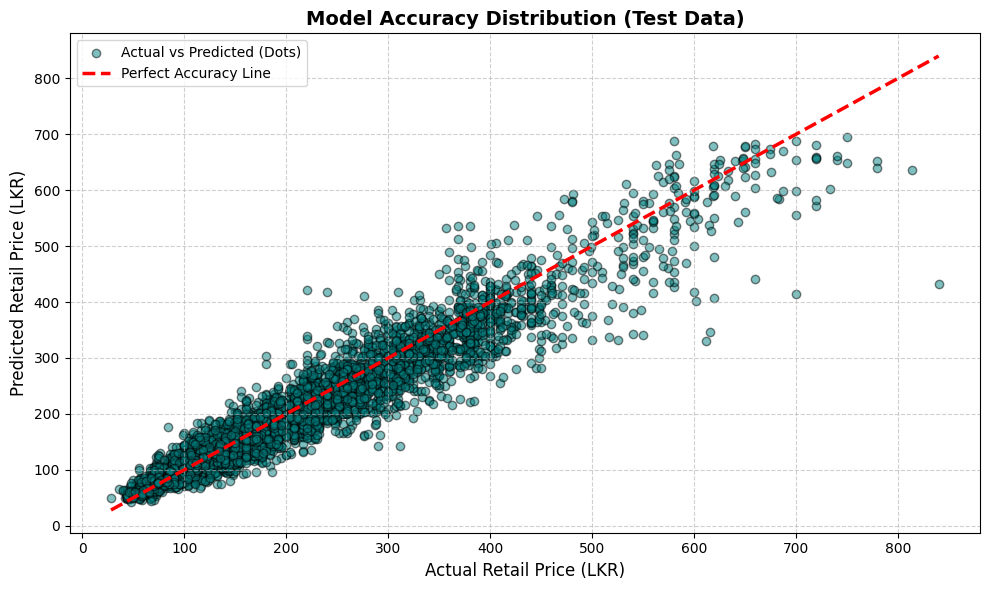

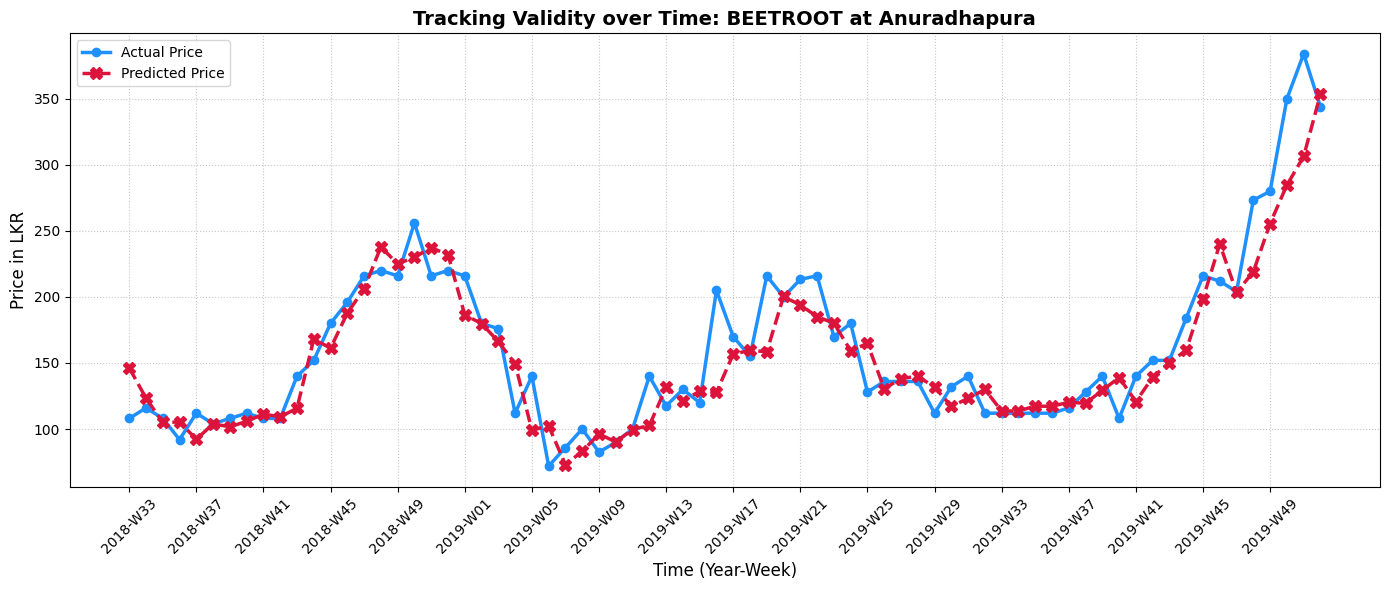

In [1]:
# ───────────────────────────────────────────────────
# Standalone Visualization Code: Test Data Validation
# ───────────────────────────────────────────────────
# Run this cell to visually evaluate model predictions on the unseen test data.
# It plots an overall Scatter Accuracy Graph and a Time-Series Line/Dot tracking graph.

import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

def visualize_test_predictions():
    # Paths
    data_path  = r'C:\Users\Ranuga\Data Science Project\3. Data Preprocessing\3.7 - Combining Datasets\Outputs\Final_Combined_data.csv'
    output_dir = r'C:\Users\Ranuga\Data Science Project\5. Model Building\5.8 - Retail Price Ensemble Models\XGBoost + LightBGM'
    model_path = os.path.join(output_dir, 'Models', 'xgb_lgbm_advanced_ensemble_optuna_model.joblib')
    
    if not os.path.exists(model_path):
        print(f"Model not found at {model_path}. Please train the model first.")
        return

    print("Reconstructing Test Set exactly as trained...")
    df = pd.read_csv(data_path)
    df.drop(columns=['code'], inplace=True, errors='ignore')

    df['week_num'] = pd.to_numeric(df['week'].str.extract(r'(\d+)')[0])
    df['week_sin'] = np.sin(2 * np.pi * df['week_num'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_num'] / 52)

    regional_weather = (
        df.groupby(['Year_Week', 'vegetable_zone'])[['rain_sum', 'mean_apparent_temperature']]
        .mean().reset_index()
        .rename(columns={'rain_sum': 'reg_rain', 'mean_apparent_temperature': 'reg_temp'})
    )
    df = pd.merge(df, regional_weather, on=['Year_Week', 'vegetable_zone'], how='left')
    df.drop(columns=['Year_Week'], inplace=True, errors='ignore')

    df['season_enc'] = LabelEncoder().fit_transform(df['seasonality'].astype(str))
    df['diesel_season_int'] = df['lanka_auto_diesel_price'] * (df['season_enc'] + 1)
    df = df.sort_values(['retail_market', 'vegetable_type', 'year', 'week_num'])

    for col in ['retail_price', 'reg_rain', 'reg_temp']:
        for lag in [1, 2, 3, 4, 8]:
            df[f'{col}_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])[col].shift(lag)

    for lag in [1, 2, 3, 4, 5, 6, 8]:
        df[f'mean_farmer_price_lag_{lag}'] = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price'].shift(lag)

    df['retail_price_roll_4'] = df.groupby(['retail_market', 'vegetable_type'])['retail_price'].transform(lambda x: x.shift(1).rolling(4).mean())
    grp = df.groupby(['retail_market', 'vegetable_type'])['mean_farmer_price']
    df['farmer_price_roll_4'] = grp.transform(lambda x: x.shift(1).rolling(4).mean())
    df['farmer_price_roll_8'] = grp.transform(lambda x: x.shift(1).rolling(8).mean())
    df['farmer_price_roll_std_4'] = grp.transform(lambda x: x.shift(1).rolling(4).std())
    df['farmer_price_pct_change_1'] = grp.transform(lambda x: x.shift(1).pct_change(1, fill_method=None))

    df['mean_farmer_price_filled'] = df['mean_farmer_price'].fillna(df['mean_farmer_price_lag_1'])
    df['farmer_retail_spread_lag_1'] = df['retail_price_lag_1'] - df['mean_farmer_price_lag_1']

    df['retail_price_momentum_1_4'] = df['retail_price_lag_1'] / (df['retail_price_lag_4'] + 1e-5)
    df['farmer_price_momentum_1_4'] = df['mean_farmer_price_lag_1'] / (df['mean_farmer_price_lag_4'] + 1e-5)

    df_ready = df.dropna(subset=['retail_price_lag_8', 'mean_farmer_price_lag_8', 'farmer_price_roll_8', 'retail_price_momentum_1_4']).copy()

    for col in ['retail_market', 'vegetable_type', 'vegetable_zone']:
        df_ready[f'{col}_enc'] = LabelEncoder().fit_transform(df_ready[col].astype(str))

    # Re-apply strict 80/20 train/test split
    test_list = []
    for _, group in df_ready.groupby(['retail_market', 'vegetable_type']):
        split = int(len(group) * 0.8)
        test_list.append(group.iloc[split:])
    test_df = pd.concat(test_list)

    print("Loading Trained Saved Model...")
    bundle = joblib.load(model_path)
    X_test = test_df[bundle['features']]
    y_test = test_df['retail_price'].values
    
    print("Executing Predictions...")
    pred_xgb_log = bundle['xgb'].predict(X_test)
    pred_lgb_log = bundle['lgb'].predict(X_test)
    
    # Invert log1p back to raw prices
    pred_xgb_raw = np.expm1(pred_xgb_log)
    pred_lgb_raw = np.expm1(pred_lgb_log)
    
    w_xgb = bundle['weights']['xgb']
    w_lgb = bundle['weights']['lgb']
    final_preds = (w_xgb * pred_xgb_raw) + (w_lgb * pred_lgb_raw)
    
    test_df['predicted_price'] = final_preds

    # =====================================================================
    # Plot 1: Scatter Graph (Predicted vs Actual) 
    # =====================================================================
    plt.figure(figsize=(10, 6))
    # Dot graph representing predictions
    plt.scatter(y_test, final_preds, alpha=0.5, color='teal', edgecolor='k', marker='o', label='Actual vs Predicted (Dots)')
    
    # Line graph representing perfect mathematical accuracy (y = x)
    min_val = min(np.min(y_test), np.min(final_preds))
    max_val = max(np.max(y_test), np.max(final_preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5, label='Perfect Accuracy Line')
    
    plt.title('Model Accuracy Distribution (Test Data)', fontsize=14, fontweight='bold')
    plt.xlabel('Actual Retail Price (LKR)', fontsize=12)
    plt.ylabel('Predicted Retail Price (LKR)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # =====================================================================
    # Plot 2: Validation Time-Series Tracking (Line + Dot Graph)
    # =====================================================================
    # Extract the market/vegetable combo with the most test data rows to visualize time tracking
    top_combo = test_df.groupby(['retail_market', 'vegetable_type']).size().idxmax()
    sample_df = test_df[(test_df['retail_market'] == top_combo[0]) & (test_df['vegetable_type'] == top_combo[1])]
    
    sample_df = sample_df.sort_values(['year', 'week_num'])
    sample_df['Time'] = sample_df['year'].astype(str) + '-W' + sample_df['week_num'].astype(str).str.zfill(2)

    plt.figure(figsize=(14, 6))
    
    # Line+Dot graph for Actuals
    plt.plot(sample_df['Time'], sample_df['retail_price'], 
             marker='o', markersize=6, linestyle='-', color='dodgerblue', linewidth=2.5, label='Actual Price')
    
    # Line+Dot graph for Predictions
    plt.plot(sample_df['Time'], sample_df['predicted_price'], 
             marker='X', markersize=8, linestyle='--', color='crimson', linewidth=2.5, label='Predicted Price')
    
    plt.title(f'Tracking Validity over Time: {top_combo[1]} at {top_combo[0]}', fontsize=14, fontweight='bold')
    plt.xlabel('Time (Year-Week)', fontsize=12)
    plt.ylabel('Price in LKR', fontsize=12)
    
    # Smart X-Axis tick skipping
    ticks = np.arange(0, len(sample_df), max(1, len(sample_df)//15))
    plt.xticks(ticks, sample_df['Time'].iloc[ticks], rotation=45)
    
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    visualize_test_predictions()

In [ ]:
conda install -c conda-forge pillow

^C
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: ...working... 

Note: you may need to restart the kernel to use updated packages.
